# Isolation Forest:

### Importação das bibliotecas:

In [1]:
import pandas as pd
import numpy as np
import os
import glob
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 12

### 2. Carregamento de Dados e a Nova Metodologia

Neste notebook, nossa abordagem muda fundamentalmente.

**O Objetivo:** Treinar um modelo que aprenda o que é tráfego **"normal"** (`BENIGN`) de forma tão precisa que qualquer desvio, por menor que seja, seja sinalizado como uma **"anomalia"**.

**A Metodologia:**
1.  Carregaremos o dataset completo como sempre.
2.  Dividiremos os dados em treino e teste para manter a consistência.
3.  **A Etapa Crucial:** Para o treinamento do `IsolationForest`, usaremos **apenas** as amostras do conjunto de treino que pertencem à classe `BENIGN`.
4.  O modelo treinado será então usado para fazer previsões no conjunto de teste **completo**, para vermos se ele consegue "caçar" os ataques (especialmente os ataques web) que os outros modelos não viram.

**Nota:** O `IsolationForest` é um modelo baseado em árvores, portanto, a **padronização de features não é necessária**.

In [2]:
# --- 1. Define os caminhos ---
try:
    project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
except:
    project_root = os.getcwd()

model_dir = os.path.join(project_root, 'models')
data_dir = os.path.join(project_root, 'MachineLearningCSV', 'MachineLearningCVE')

print(f"Diretório de modelos: {model_dir}")
print(f"Diretório de dados: {data_dir}")

# --- 2. Carrega os artefatos de pré-processamento ---
print("\nCarregando artefatos de pré-processamento...")
try:
    label_encoder = joblib.load(os.path.join(model_dir, 'label_encoder.joblib'))
    features_realistas = joblib.load(os.path.join(model_dir, 'features_realistas.joblib'))
    # Pega o índice numérico da classe 'BENIGN'
    benign_label_index = list(label_encoder.classes_).index('BENIGN')
    print(f"  - Artefatos carregados. A classe 'BENIGN' corresponde ao rótulo '{benign_label_index}'.")
except Exception as e:
    raise RuntimeError(f"ERRO: Não foi possível carregar os artefatos. Verifique o notebook 01. Erro: {e}")

# --- 3. Carrega e limpa o dataset completo ---
print("\nCarregando e limpando o dataset completo...")
todos_os_arquivos = glob.glob(os.path.join(data_dir, "*.csv"))
dados = pd.concat((pd.read_csv(f, low_memory=False) for f in todos_os_arquivos), ignore_index=True)
dados.columns = dados.columns.str.strip()
for col in dados.columns:
    if dados[col].dtype == 'object' and col != 'Label':
        dados[col] = pd.to_numeric(dados[col], errors='coerce')
dados.replace([np.inf, -np.inf], np.nan, inplace=True)
dados.dropna(inplace=True)
print("  - Dataset carregado e limpo.")

# --- 4. Separa features e labels ---
X_bruto = dados.drop('Label', axis=1)
y_bruto = dados['Label']
y_codificado = label_encoder.transform(y_bruto)
X_realista = X_bruto[features_realistas]

# --- 5. Divisão em Treino e Teste ---
print("\nDividindo os dados em treino e teste...")
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_realista, y_codificado, test_size=0.3, random_state=42, stratify=y_codificado
)
print(f"  - Shape do conjunto de treino completo: {X_treino.shape}")
print(f"  - Shape do conjunto de teste completo: {X_teste.shape}")

# --- 6. A Etapa Crucial: Isolar os Dados de Treino BENIGN ---
print("\nIsolando amostras 'BENIGN' para o treinamento...")
X_treino_benign = X_treino[y_treino == benign_label_index]
print(f"  - Shape do conjunto de treino 'BENIGN': {X_treino_benign.shape}")

print("\n--- Setup concluído ---")

Diretório de modelos: /home/henrique/PycharmProjects/ndr-tcc/models
Diretório de dados: /home/henrique/PycharmProjects/ndr-tcc/MachineLearningCSV/MachineLearningCVE

Carregando artefatos de pré-processamento...
  - Artefatos carregados. A classe 'BENIGN' corresponde ao rótulo '0'.

Carregando e limpando o dataset completo...
  - Dataset carregado e limpo.

Dividindo os dados em treino e teste...
  - Shape do conjunto de treino completo: (1979513, 14)
  - Shape do conjunto de teste completo: (848363, 14)

Isolando amostras 'BENIGN' para o treinamento...
  - Shape do conjunto de treino 'BENIGN': (1589924, 14)

--- Setup concluído ---


### 3. Treinamento do Modelo Isolation Forest

 O treinamento será feito **apenas** com os dados `X_treino_benign`.
 O modelo aprenderá a "forma" do tráfego normal.

 Parâmetros importantes:
 - `n_estimators=100`: O número de árvores a serem construídas. 100 é um bom ponto de partida.
 - `contamination='auto'`: Um parâmetro crucial. 'auto' usa o algoritmo original, mas em versões mais novas do scikit-learn, o padrão mudará. Definir explicitamente nos protege de mudanças futuras. Ele estima a proporção de outliers nos dados.
 - `random_state=42`: Para reprodutibilidade.
 - `n_jobs=-1`: Para usar todos os núcleos de CPU e acelerar o treinamento.

In [3]:
print("--- Iniciando o treinamento do Isolation Forest ---")
print(f"O modelo será treinado com {len(X_treino_benign)} amostras de tráfego 'BENIGN'.")

# Instancia o modelo
iso_forest = IsolationForest(
    n_estimators=100,
    contamination='auto',
    random_state=42,
    n_jobs=-1
)

# Treina o modelo APENAS com os dados benignos
iso_forest.fit(X_treino_benign)

print("\n--- Treinamento concluído ---")

--- Iniciando o treinamento do Isolation Forest ---
O modelo será treinado com 1589924 amostras de tráfego 'BENIGN'.

--- Treinamento concluído ---


## 4. Avaliação do Modelo de Detecção de Anomalias

A avaliação aqui é diferente. Não estamos mais interessados em classificar 15 tipos de ataque.
Nossa pergunta é binária: **o modelo conseguiu separar o tráfego `BENIGN` do tráfego de `ATAQUE`?**

**Metodologia de Avaliação:**
1.  Faremos previsões no conjunto de teste completo (`X_teste`). O modelo retornará `1` para "normal" (inlier) e `-1` para "anômalo" (outlier).
2.  Para comparar com nossos rótulos verdadeiros (`y_teste`), vamos converter nosso problema para um formato binário:
    - `y_teste` será `1` se for `BENIGN` e `-1` se for qualquer tipo de ataque.
3.  Geraremos um `classification_report` e uma matriz de confusão para este problema binário.
4.  **O Foco Principal:** Olharemos o **recall** da classe "Ataque". Um recall alto significa que o modelo foi bem-sucedido em "caçar" a maioria dos ataques, marcando-os como anomalias.

--- Iniciando a avaliação do Isolation Forest ---
Valores únicos nas previsões: [-1  1]
Lembrete: 1 = Normal (Inlier), -1 = Anômalo (Outlier)

--- Relatório de Classificação (Binário: Normal vs. Anômalo) ---
                  precision    recall  f1-score   support

Ataque (Anômalo)       0.17      0.19      0.18    166967
Normal (Benigno)       0.80      0.78      0.79    681396

        accuracy                           0.66    848363
       macro avg       0.49      0.48      0.49    848363
    weighted avg       0.67      0.66      0.67    848363



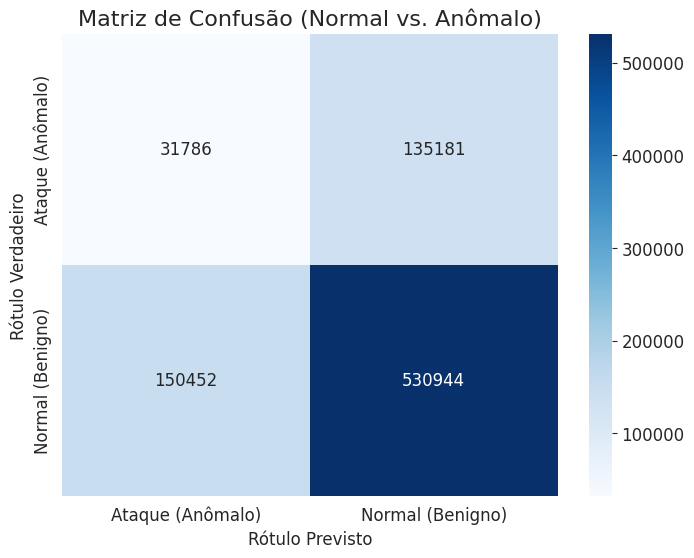

In [4]:
print("--- Iniciando a avaliação do Isolation Forest ---")

# --- Passo 1: Fazer previsões no conjunto de teste completo ---
y_pred_iso = iso_forest.predict(X_teste)

print(f"Valores únicos nas previsões: {np.unique(y_pred_iso)}")
print("Lembrete: 1 = Normal (Inlier), -1 = Anômalo (Outlier)")

# --- Passo 2: Converter os rótulos verdadeiros para o formato binário ---
# Criamos uma nova variável para não modificar a original
# Se o rótulo for 'BENIGN' (índice 0), marcamos como 1 (Normal).
# Se for qualquer outra coisa (ataque), marcamos como -1 (Anômalo).
y_teste_binario = np.where(y_teste == benign_label_index, 1, -1)

# --- Passo 3: Gerar o Relatório de Classificação Binário ---
print("\n--- Relatório de Classificação (Binário: Normal vs. Anômalo) ---")

# Define os nomes das nossas novas classes binárias
target_names_binario = ['Ataque (Anômalo)', 'Normal (Benigno)']

# Gera o relatório
print(classification_report(y_teste_binario, y_pred_iso, target_names=target_names_binario))

# --- Passo 4: Gerar a Matriz de Confusão Binária ---
cm_binaria = confusion_matrix(y_teste_binario, y_pred_iso)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_binaria, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names_binario,
            yticklabels=target_names_binario)
plt.title('Matriz de Confusão (Normal vs. Anômalo)', fontsize=16)
plt.ylabel('Rótulo Verdadeiro', fontsize=12)
plt.xlabel('Rótulo Previsto', fontsize=12)
plt.show()

### 5. Análise Detalhada: O IsolationForest Conseguiu "Caçar" os Ataques Raros?

O relatório binário nos deu uma visão geral, mas nossa missão principal era ver se esta abordagem poderia detectar os ataques que os classificadores supervisionados ignoraram.

**Metodologia:**
1. Vamos agrupar nosso conjunto de teste pela classe de ataque **original**.
2. Para cada classe, vamos calcular a porcentagem de amostras que o `IsolationForest` marcou como **Anômalo (-1)**.
3. Isso nos dirá o **"recall de detecção de anomalia"** para cada tipo de ataque, incluindo `SQL Injection` e `XSS`.

In [5]:
# Cria um DataFrame com os resultados para facilitar a análise
df_resultados = pd.DataFrame({
    'y_verdadeiro': y_teste,
    'y_pred_iso': y_pred_iso
})

# Mapeia os índices numéricos de volta para os nomes das classes
df_resultados['nome_classe'] = label_encoder.inverse_transform(df_resultados['y_verdadeiro'])

# Agrupa por classe e calcula as métricas
# Para cada classe, conta o total de amostras e quantas foram marcadas como anomalia (-1)
analise_por_classe = df_resultados.groupby('nome_classe').agg(
    total_amostras=('y_pred_iso', 'count'),
    detectadas_como_anomalia=('y_pred_iso', lambda x: (x == -1).sum())
).reset_index()

# Calcula a porcentagem de detecção (recall de anomalia)
analise_por_classe['recall_anomalia_%'] = (analise_por_classe['detectadas_como_anomalia'] / analise_por_classe['total_amostras']) * 100

# Ordena para ver os resultados mais interessantes
analise_final = analise_por_classe.sort_values(by='recall_anomalia_%', ascending=False)

print("--- Recall de Detecção de Anomalia por Classe de Ataque Original ---")
display(analise_final.style.format({'recall_anomalia_%': '{:.2f}%'}))

--- Recall de Detecção de Anomalia por Classe de Ataque Original ---


,nome_classe,total_amostras,detectadas_como_anomalia,recall_anomalia_%
14,Web Attack � XSS,196,182,92.86%
12,Web Attack � Brute Force,452,382,84.51%
9,Infiltration,11,7,63.64%
7,FTP-Patator,2380,1200,50.42%
6,DoS slowloris,1739,584,33.58%
4,DoS Hulk,69037,17730,25.68%
10,PortScan,47641,11214,23.54%
5,DoS Slowhttptest,1650,387,23.45%
0,BENIGN,681396,150452,22.08%
1,Bot,587,78,13.29%


### 6. Otimização: Ajustando a Sensibilidade do Caçador

O recall de 22% para a classe `BENIGN` (nosso índice de falsos positivos) é alto.
Isso acontece porque o parâmetro `contamination='auto'` pode estar sendo muito agressivo.

Vamos treinar um novo modelo com um valor de `contamination` explícito e mais baixo (ex: 0.05, ou 5%)
para ver se conseguimos reduzir o número de falsos positivos sem sacrificar muito a detecção dos ataques raros.

In [6]:
print("--- Treinando um modelo Isolation Forest Otimizado ---")

# Instancia um novo modelo com contamination explícito
iso_forest_otimizado = IsolationForest(
    n_estimators=100,
    contamination=0.05,  # Assumimos que ~5% dos dados podem ser anômalos
    random_state=42,
    n_jobs=-1
)

# Treina o modelo
iso_forest_otimizado.fit(X_treino_benign)

print("\n--- Avaliando o Modelo Otimizado ---")

# Gera previsões
y_pred_iso_otimizado = iso_forest_otimizado.predict(X_teste)

# Gera a mesma análise detalhada
df_resultados_otimizado = pd.DataFrame({
    'y_verdadeiro': y_teste,
    'y_pred_iso': y_pred_iso_otimizado
})
df_resultados_otimizado['nome_classe'] = label_encoder.inverse_transform(df_resultados_otimizado['y_verdadeiro'])

analise_otimizada = df_resultados_otimizado.groupby('nome_classe').agg(
    total_amostras=('y_pred_iso', 'count'),
    detectadas_como_anomalia=('y_pred_iso', lambda x: (x == -1).sum())
).reset_index()

analise_otimizada['recall_anomalia_%'] = (analise_otimizada['detectadas_como_anomalia'] / analise_otimizada['total_amostras']) * 100
analise_final_otimizada = analise_otimizada.sort_values(by='recall_anomalia_%', ascending=False)

print("\n--- Recall de Detecção (Modelo Otimizado com contamination=0.05) ---")
display(analise_final_otimizada.style.format({'recall_anomalia_%': '{:.2f}%'}))


--- Treinando um modelo Isolation Forest Otimizado ---

--- Avaliando o Modelo Otimizado ---

--- Recall de Detecção (Modelo Otimizado com contamination=0.05) ---


,nome_classe,total_amostras,detectadas_como_anomalia,recall_anomalia_%
9,Infiltration,11,6,54.55%
6,DoS slowloris,1739,524,30.13%
4,DoS Hulk,69037,17631,25.54%
5,DoS Slowhttptest,1650,266,16.12%
0,BENIGN,681396,34130,5.01%
7,FTP-Patator,2380,2,0.08%
1,Bot,587,0,0.00%
3,DoS GoldenEye,3088,0,0.00%
2,DDoS,38408,0,0.00%
8,Heartbleed,3,0,0.00%


### 7. Busca pelo "Meio Termo": Encontrando o Ponto Ideal de Contaminação

A sua observação está corretíssima. Passar de 22% de falsos positivos para 0% de detecção de ataques web é um salto muito grande. O ponto ideal de performance deve estar em algum lugar nesse intervalo.

Vamos agora testar sistematicamente alguns valores de `contamination` entre 0.05 e 0.22 para encontrar o melhor trade-off possível entre a detecção de ataques web e a geração de falsos positivos.

In [8]:
# Lista de "meios-termos" que vamos testar
contamination_values = [0.15, 0.12, 0.10, 0.08]

print("--- Iniciando a busca pelo valor ideal de 'contamination' ---")

for cont_level in contamination_values:
    print(f"\n" + "="*50)
    print(f"  RESULTADOS PARA contamination = {cont_level:.2f}")
    print("="*50)

    # Treina um novo modelo com o nível de contaminação atual
    iso_forest_teste = IsolationForest(
        n_estimators=100,
        contamination=cont_level,
        random_state=42,
        n_jobs=-1
    )
    iso_forest_teste.fit(X_treino_benign)

    # Gera previsões
    y_pred_teste = iso_forest_teste.predict(X_teste)

    # --- Calcula as métricas chave ---
    df_temp = pd.DataFrame({'y_verdadeiro': y_teste, 'y_pred_iso': y_pred_teste})
    df_temp['nome_classe'] = label_encoder.inverse_transform(df_temp['y_verdadeiro'])

    analise_temp = df_temp.groupby('nome_classe').agg(
        total_amostras=('y_pred_iso', 'count'),
        detectadas_como_anomalia=('y_pred_iso', lambda x: (x == -1).sum())
    ).reset_index()
    analise_temp['recall_anomalia_%'] = (analise_temp['detectadas_como_anomalia'] / analise_temp['total_amostras']) * 100

    # Ordena e exibe a tabela completa para este nível
    analise_final_teste = analise_temp.sort_values(by='recall_anomalia_%', ascending=False)

    display(analise_final_teste.style.format({'recall_anomalia_%': '{:.2f}%'}))

print("\n--- Busca concluída ---")

--- Iniciando a busca pelo valor ideal de 'contamination' ---

  RESULTADOS PARA contamination = 0.15


,nome_classe,total_amostras,detectadas_como_anomalia,recall_anomalia_%
14,Web Attack � XSS,196,182,92.86%
12,Web Attack � Brute Force,452,382,84.51%
9,Infiltration,11,7,63.64%
7,FTP-Patator,2380,1200,50.42%
6,DoS slowloris,1739,584,33.58%
4,DoS Hulk,69037,17730,25.68%
5,DoS Slowhttptest,1650,387,23.45%
0,BENIGN,681396,102604,15.06%
10,PortScan,47641,5175,10.86%
1,Bot,587,32,5.45%



  RESULTADOS PARA contamination = 0.12


,nome_classe,total_amostras,detectadas_como_anomalia,recall_anomalia_%
9,Infiltration,11,7,63.64%
7,FTP-Patator,2380,1199,50.38%
6,DoS slowloris,1739,524,30.13%
4,DoS Hulk,69037,17678,25.61%
5,DoS Slowhttptest,1650,268,16.24%
0,BENIGN,681396,82233,12.07%
1,Bot,587,28,4.77%
10,PortScan,47641,1711,3.59%
11,SSH-Patator,1769,6,0.34%
3,DoS GoldenEye,3088,0,0.00%



  RESULTADOS PARA contamination = 0.10


,nome_classe,total_amostras,detectadas_como_anomalia,recall_anomalia_%
9,Infiltration,11,7,63.64%
7,FTP-Patator,2380,1199,50.38%
6,DoS slowloris,1739,524,30.13%
4,DoS Hulk,69037,17678,25.61%
5,DoS Slowhttptest,1650,267,16.18%
0,BENIGN,681396,68040,9.99%
1,Bot,587,28,4.77%
10,PortScan,47641,720,1.51%
11,SSH-Patator,1769,6,0.34%
3,DoS GoldenEye,3088,0,0.00%



  RESULTADOS PARA contamination = 0.08


,nome_classe,total_amostras,detectadas_como_anomalia,recall_anomalia_%
9,Infiltration,11,7,63.64%
6,DoS slowloris,1739,524,30.13%
4,DoS Hulk,69037,17640,25.55%
5,DoS Slowhttptest,1650,267,16.18%
0,BENIGN,681396,54129,7.94%
10,PortScan,47641,439,0.92%
1,Bot,587,1,0.17%
7,FTP-Patator,2380,2,0.08%
11,SSH-Patator,1769,1,0.06%
3,DoS GoldenEye,3088,0,0.00%



--- Busca concluída ---


### 8. Conclusão e Salvamento do Modelo Final

A busca pelo valor ideal de `contamination` revelou um "ponto de ruptura" claro.
Valores abaixo de 0.15 eliminam completamente a detecção dos ataques web, que é o objetivo principal desta camada.

Portanto, concluímos que o modelo com `contamination=0.15` oferece o melhor trade-off para a nossa arquitetura. Ele maximiza a detecção de ataques furtivos, e os 15% de falsos positivos gerados serão tratados pela nossa Camada 2 (o Ensemble).

Vamos treinar e salvar nosso modelo final.

In [9]:
print("--- Treinando e Salvando o Modelo Isolation Forest Final ---")

# Define o nosso parâmetro campeão
contamination_final = 0.15

# Instancia o modelo final
iso_forest_final = IsolationForest(
    n_estimators=100,
    contamination=contamination_final,
    random_state=42,
    n_jobs=-1
)

# Treina o modelo com os dados benignos
iso_forest_final.fit(X_treino_benign)

print(f"\nModelo final treinado com contamination = {contamination_final}")

# --- Salva o modelo final ---
iso_forest_path = os.path.join(model_dir, 'isolation_forest_model.joblib')
joblib.dump(iso_forest_final, iso_forest_path)

print(f"Modelo Isolation Forest final salvo em: {iso_forest_path}")

# --- Verificação Final ---
print("\n--- Verificando arquivos salvos no diretório 'models' ---")
print(sorted(os.listdir(model_dir)))

--- Treinando e Salvando o Modelo Isolation Forest Final ---

Modelo final treinado com contamination = 0.15
Modelo Isolation Forest final salvo em: /home/henrique/PycharmProjects/ndr-tcc/models/isolation_forest_model.joblib

--- Verificando arquivos salvos no diretório 'models' ---
['catboost_model.joblib', 'ensemble_model.joblib', 'features_realistas.joblib', 'isolation_forest_model.joblib', 'label_encoder.joblib', 'mlp_model.joblib', 'random_forest_model.joblib', 'top_15_features.joblib', 'xgboost_model.joblib']
